# Head

In [1]:
import json
import pandas as pd

records = []
with open('/home/zqlyu2/projects/TLDR/data/paper_html_10.1038/abs_annotation/abs_sent_rhetorical_tag.jsonl', 'r') as f:
    for line in f.readlines():
        records.append(json.loads(line))

df_abs = pd.DataFrame.from_records(records)
df_abs

,sentences,labels
0,[The origin and taxonomic status of domesticat...,"[BACKGROUND, BACKGROUND, BACKGROUND, METHODS, ..."
1,[Abstract The domestic pig originates from the...,"[BACKGROUND, METHODS, RESULTS, RESULTS, BACKGR..."
2,[We previously mapped a quantitative trait loc...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD..."
3,[A genome-wide linkage disequilibrium (LD) map...,"[BACKGROUND, METHODS, RESULTS, RESULTS, RESULT..."
4,[The European wild boar was crossed with the d...,"[BACKGROUND, RESULTS, METHODS, CONCLUSIONS]"
...,...,...
35631,[OBJECTIVE—Regulatory T-cells (Tregs) have cat...,[]
35632,[Engineering cytokine-receptor pairs Interleuk...,"[BACKGROUND, BACKGROUND, OBJECTIVE, METHODS, R..."
35633,[T cells target peptide combos One of the endu...,"[BACKGROUND, METHODS, RESULTS, RESULTS, CONCLU..."
35634,[Polymorphic HLAs form the primary immune barr...,"[BACKGROUND, BACKGROUND, METHODS, METHODS, RES..."


In [2]:
import pandas as pd
from pathlib import Path
home = Path.home()

models = ['gemma3', 'deepseek_r1', 'gpt_oss','llama4', 'qwen3']

suffixes = None

if suffixes is not None:
    csv_files = [home / f'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/{model}{suffixes}.txt' for model in models]
else:
    csv_files = [home / f'projects/TLDR/data/paper_html_10.1038/abs_annotation/generated_annotations/{model}.txt' for model in models]

df_sum = pd.read_csv(home / 'projects/TLDR/data/paper_html_10.1038/abs_annotation/test.tsv', sep='\t')
for model, csv_file in zip(models, csv_files):
    single_df = pd.read_csv(csv_file, sep='\t', header=None, names=[model], skip_blank_lines=False)
    df_sum = df_sum.join(single_df)

df_sum['qwen3'] = df_sum['qwen3'].fillna('')
df_sum

,doi,paper_id,abstract,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
0,10.1073/pnas.91.7.2757,107202074,The origin and taxonomic status of domesticate...,A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...
1,10.1093/genetics/154.4.1785,83366887,Abstract The domestic pig originates from the ...,Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...
2,10.1073/pnas.96.16.9252,122095374,We previously mapped a quantitative trait locu...,This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...
3,10.1101/gr.10.2.220,100831446,A genome-wide linkage disequilibrium (LD) map ...,The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...
4,10.1126/science.8134840,17452622,The European wild boar was crossed with the do...,The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reported here constitute a comprehens...,Identifies a major QTL on chromosome 4 underly...
...,...,...,...,...,...,...,...,...,...
35631,10.2337/db08-1168,4860455,OBJECTIVE—Regulatory T-cells (Tregs) have cata...,This article describes the good manufacturing ...,This study describes an efficient protocol for...,This study evaluates methods for isolating and...,The authors compare human T‑reg isolation stra...,These studies suggest that isolation and expan...,This study demonstrates that CD4+CD127lo/−CD25...
35632,10.1126/science.aar3246,4860145,Engineering cytokine-receptor pairs Interleuki...,This study reports the generation of an orthog...,Reference 48 describes the engineering of a sy...,This study describes the engineering of synthe...,Sockolosky et al. engineered an orthogonal IL‑...,This study demonstrates that orthogonal IL-2 a...,This work describes engineered synthetic IL-2 ...
35633,10.1126/science.aad2791,62290395,T cells target peptide combos One of the endur...,This article shows that some diabetogenic T ce...,Reference 51 shows that autoreactive T cells c...,This study identifies hybrid peptides as targe...,Delong et al. used mass‑spectrometry–based pep...,This study identifies an important mechanism u...,This study identifies autoimmune T cell recogn...
35634,10.1073/pnas.1902566116,82979762,Polymorphic HLAs form the primary immune barri...,This article describes the development of gene...,This work demonstrates that a combined strateg...,This study presents a novel strategy for enhan...,The authors used multiplex CRISPR editing to d...,This study presents a comprehensive strategy t...,This study reports a genome-editing strategy t...


In [3]:
df = df_abs.join(df_sum[['annotation']+models])

In [4]:
for index in pd.read_csv(home / "projects/TLDR/dataset_description/invalid_entry_in_test.txt", sep='\t', header=None).values.flatten().tolist():
    df = df.drop(index-2)  # Adjusting for zero-based index

# Try re-tagging

In [61]:
from tqdm import tqdm
import ollama
import re

def remove_think_content(text):
    # remove all <think>...</think> and its content (including multi-line)
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE).strip()

def filter_short_sentences(sentences, min_length=8):
    return [sent for sent in sentences if len(sent.split()) >= min_length]

for index, row in tqdm(df[df['labels'].apply(len) == 0].iterrows(), total=len(df[df['labels'].apply(len) == 0])):
    sents = filter_short_sentences(row['sentences'])
    prompt_payload = {
        "sentence_count": len(sents),
        "sentences": sents
    }
    while True:
        response = ollama.generate(model='rhetorical_tagger', 
                                   prompt=json.dumps(prompt_payload), 
                                   stream=False, 
                                   think=False)
        
        content = response['response']
        filtered_content = remove_think_content(content)
        labels = json.loads(filtered_content)
        if len(labels) == len(sents):
            df.at[index, 'labels'] = labels
            df.at[index, 'sentences'] = sents
            break
        else:
            print("Input sentence length:", len(sents), "Output label length:", len(labels))
            print("snetences:")
            for sent in sents:
                print(sent) 
            print(f"Retrying for index {index} due to length mismatch.\n")

  0%|                                                                                                      | 0/1591 [00:00<?, ?it/s]

Input sentence length: 21 Output label length: 20
snetences:
The latency between the appearance of a popout search display and the eye movement to the oddball target of the display varies from trial to trial in both humans and monkeys.
The source of the delay and variability of reaction time is unknown but has been attributed to as yet poorly defined decision processes.
2. We recorded neural activity in the frontal eye field (FEF), an area regarded as playing a central role in producing purposeful eye movements, of monkeys (Macaca mulatta) performing a popout visual search task.
Eighty-four neurons with visually evoked activity were analyzed.
Twelve of these neurons had a phasic response associated with the presentation of the visual stimulus.
The remaining neurons had more tonic responses that persisted through the saccade.
Many of the neurons with more tonic responses resembled visuomovement cells in that they had activity that increased before a saccade into their response field.
Th

  0%|                                                                                                      | 0/1591 [00:06<?, ?it/s]


KeyboardInterrupt: 

# Count word appearance in abstracts

In [5]:
def only_contain_valid_labels(label_list, valid_labels):
    return all(label in valid_labels for label in label_list)

df_filtered = df[df['labels'].apply(len) > 0]
df_filtered = df_filtered[df_filtered['labels'].apply(lambda x: only_contain_valid_labels(x, 
                                                            ['BACKGROUND', 'OBJECTIVE', 'METHODS', 
                                                             'RESULTS', 'CONCLUSIONS']))].copy()
df_filtered

,sentences,labels,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3
0,[The origin and taxonomic status of domesticat...,"[BACKGROUND, BACKGROUND, BACKGROUND, METHODS, ...",A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...
1,[Abstract The domestic pig originates from the...,"[BACKGROUND, METHODS, RESULTS, RESULTS, BACKGR...",Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...
2,[We previously mapped a quantitative trait loc...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...
3,[A genome-wide linkage disequilibrium (LD) map...,"[BACKGROUND, METHODS, RESULTS, RESULTS, RESULT...",The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...
4,[The European wild boar was crossed with the d...,"[BACKGROUND, RESULTS, METHODS, CONCLUSIONS]",The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reported here constitute a comprehens...,Identifies a major QTL on chromosome 4 underly...
...,...,...,...,...,...,...,...,...
35630,[Abstract We developed an approach that increa...,"[BACKGROUND, METHODS, METHODS, METHODS, RESULT...",First study redirecting T reg cells using a ch...,This reference describes a chimeric receptor a...,This study introduces a novel therapeutic stra...,This study shows that CD4⁺CD25⁺ regulatory T c...,This study demonstrates that antigen-specific ...,This study describes antigen-specific redirect...
35632,[Engineering cytokine-receptor pairs Interleuk...,"[BACKGROUND, BACKGROUND, OBJECTIVE, METHODS, R...",This study reports the generation of an orthog...,Reference 48 describes the engineering of a sy...,This study describes the engineering of synthe...,Sockolosky et al. engineered an orthogonal IL‑...,This study demonstrates that orthogonal IL-2 a...,This work describes engineered synthetic IL-2 ...
35633,[T cells target peptide combos One of the endu...,"[BACKGROUND, METHODS, RESULTS, RESULTS, CONCLU...",This article shows that some diabetogenic T ce...,Reference 51 shows that autoreactive T cells c...,This study identifies hybrid peptides as targe...,Delong et al. used mass‑spectrometry–based pep...,This study identifies an important mechanism u...,This study identifies autoimmune T cell recogn...
35634,[Polymorphic HLAs form the primary immune barr...,"[BACKGROUND, BACKGROUND, METHODS, METHODS, RES...",This article describes the development of gene...,This work demonstrates that a combined strateg...,This study presents a novel strategy for enhan...,The authors used multiplex CRISPR editing to d...,This study presents a comprehensive strategy t...,This study reports a genome-editing strategy t...


# Tokenization

In [6]:
import nltk
from tqdm import tqdm

df_filtered['abs_words'] = None
df_filtered['word_appearance'] = None
df_filtered['role_word_counts'] = None

df_filtered['human_words'] = None
df_filtered['gemma3_words'] = None
df_filtered['deepseek_r1_words'] = None
df_filtered['gpt_oss_words'] = None
df_filtered['llama4_words'] = None
df_filtered['qwen3_words'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    sents = row['sentences']
    word_appearance = {}
    role_word_counts = {r: 0 for r in ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']}
    stopwords = set(nltk.corpus.stopwords.words('english'))
    abs_words = []

    for sent, label in zip(sents, row['labels']):
        one_sent_words = [word for word in nltk.word_tokenize(sent) if word.lower() not in stopwords and word.isalpha()]
        abs_words.extend(one_sent_words)
        role_word_counts[label] += len(one_sent_words)  # 统计每个 role 的词数
        for word in one_sent_words:
            if word not in word_appearance:
                word_appearance[word] = {}
            if label not in word_appearance[word]:
                word_appearance[word][label] = 0
            word_appearance[word][label] += 1

    df_filtered.at[index, 'abs_words'] = abs_words
    df_filtered.at[index, 'word_appearance'] = word_appearance
    df_filtered.at[index, 'role_word_counts'] = role_word_counts

    human_words = [word for word in nltk.word_tokenize(row['annotation']) if word.lower() not in stopwords and word.isalpha()]
    gemma3_words = [word for word in nltk.word_tokenize(row['gemma3']) if word.lower() not in stopwords and word.isalpha()]
    deepseek_r1_words = [word for word in nltk.word_tokenize(row['deepseek_r1']) if word.lower() not in stopwords and word.isalpha()]
    gpt_oss_words = [word for word in nltk.word_tokenize(row['gpt_oss']) if word.lower() not in stopwords and word.isalpha()]
    llama4_words = [word for word in nltk.word_tokenize(row['llama4']) if word.lower() not in stopwords and word.isalpha()]
    qwen3_words = [word for word in nltk.word_tokenize(row['qwen3']) if word.lower() not in stopwords and word.isalpha()]

    df_filtered.at[index, 'human_words'] = human_words
    df_filtered.at[index, 'gemma3_words'] = gemma3_words
    df_filtered.at[index, 'deepseek_r1_words'] = deepseek_r1_words
    df_filtered.at[index, 'gpt_oss_words'] = gpt_oss_words
    df_filtered.at[index, 'llama4_words'] = llama4_words
    df_filtered.at[index, 'qwen3_words'] = qwen3_words
df_filtered

100%|████████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [01:04<00:00, 523.27it/s]


,sentences,labels,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3,abs_words,word_appearance,role_word_counts,human_words,gemma3_words,deepseek_r1_words,gpt_oss_words,llama4_words,qwen3_words
0,[The origin and taxonomic status of domesticat...,"[BACKGROUND, BACKGROUND, BACKGROUND, METHODS, ...",A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...,"[origin, taxonomic, status, domesticated, catt...","{'origin': {'BACKGROUND': 1}, 'taxonomic': {'B...","{'BACKGROUND': 33, 'OBJECTIVE': 0, 'METHODS': ...","[demonstration, cattle, domesticated, two, dis...","[study, refutes, single, origin, domestic, cat...","[study, investigates, origin, taxonomy, domest...","[mtDNA, analysis, reveals, two, deep, geograph...","[study, suggests, two, distinct, domestication...","[mtDNA, analysis, reveals, ancient, divergence..."
1,[Abstract The domestic pig originates from the...,"[BACKGROUND, METHODS, RESULTS, RESULTS, BACKGR...",Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...,"[Abstract, domestic, pig, originates, Eurasian...","{'Abstract': {'BACKGROUND': 1}, 'domestic': {'...","{'BACKGROUND': 18, 'OBJECTIVE': 0, 'METHODS': ...","[Evidence, presented, independent, domesticati...","[study, provides, evidence, independent, domes...","[paper, examines, domestication, history, pigs...","[study, sequenced, mitochondrial, nuclear, gen...","[study, among, others, provides, evidence, ind...","[study, demonstrates, independent, pig, domest..."
2,[We previously mapped a quantitative trait loc...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...,"[previously, mapped, quantitative, trait, locu...","{'previously': {'BACKGROUND': 1}, 'mapped': {'...","{'BACKGROUND': 11, 'OBJECTIVE': 0, 'METHODS': ...","[paper, shows, approach, applied, mapping, qua...","[study, used, methods, identify, association, ...","[study, refines, genetic, mapping, bovine, chr...","[study, refined, quantitative, trait, locus, b...","[study, describes, approach, used, demonstrate...","[QTL, study, identifies, bovine, chromosome, h..."
3,[A genome-wide linkage disequilibrium (LD) map...,"[BACKGROUND, METHODS, RESULTS, RESULTS, RESULT...",The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...,"[linkage, disequilibrium, LD, map, generated, ...","{'linkage': {'BACKGROUND': 1, 'CONCLUSIONS': 2...","{'BACKGROUND': 17, 'OBJECTIVE': 0, 'METHODS': ...","[pattern, linkage, disequilibrium, LD, across,...","[Reference, reports, LD, Dutch, dairy, cattle,...","[study, constructs, LD, map, Dutch, dairy, cat...","[study, maps, LD, Dutch, dairy, cattle, using,...","[study, demonstrated, linkage, disequilibrium,...","[analysis, Dutch, dairy, cattle, using, micros..."
4,[The European wild boar was crossed with the d...,"[BACKGROUND, RESULTS, METHODS, CONCLUSIONS]",The first paper to show the use of divergent i...,This study identifies a major QTL on SSC4 affe...,This study identifies a significant QTL on chr...,This study used a cross between European wild ...,The data reporte

In [7]:
df_filtered['word_appearance'][0]

{'origin': {'BACKGROUND': 1},
 'taxonomic': {'BACKGROUND': 1},
 'status': {'BACKGROUND': 1},
 'domesticated': {'BACKGROUND': 1},
 'cattle': {'BACKGROUND': 2},
 'controversial': {'BACKGROUND': 1},
 'Zebu': {'BACKGROUND': 1},
 'taurine': {'BACKGROUND': 1, 'METHODS': 2, 'CONCLUSIONS': 1},
 'breeds': {'BACKGROUND': 1, 'METHODS': 3, 'RESULTS': 2},
 'differentiated': {'BACKGROUND': 1},
 'primarily': {'BACKGROUND': 1},
 'presence': {'BACKGROUND': 1},
 'absence': {'BACKGROUND': 1},
 'hump': {'BACKGROUND': 1},
 'recognized': {'BACKGROUND': 1},
 'separate': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'species': {'BACKGROUND': 1},
 'Bos': {'BACKGROUND': 2, 'CONCLUSIONS': 1},
 'indicus': {'BACKGROUND': 1},
 'taurus': {'BACKGROUND': 1, 'CONCLUSIONS': 1},
 'However': {'BACKGROUND': 1, 'RESULTS': 1},
 'widely': {'BACKGROUND': 1},
 'held': {'BACKGROUND': 1},
 'view': {'BACKGROUND': 1},
 'types': {'BACKGROUND': 1},
 'derive': {'BACKGROUND': 1},
 'single': {'BACKGROUND': 1},
 'domestication': {'BACKGROUND': 1

# Word role probability sequence

In [8]:
import numpy as np

all_roles = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']

for doc_type in ['abs', 'human', 'gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3']:
    df_filtered[f'{doc_type}_word_prob'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    for doc_type in ['abs', 'human', 'gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3']:
        words = row[f'{doc_type}_words']
        word_role_prob = []
        for i, word in enumerate(words):
            try:
                word_label_counts = row['word_appearance'][word]
                role_word_counts = row['role_word_counts']
                
                # 计算归一化的概率，考虑所有角色
                normalized_probs = {}
                for label in all_roles:
                    count = word_label_counts.get(label, 0)
                    normalized_probs[label] = (count / role_word_counts[label]) if role_word_counts[label] > 0 else 0

                # 再归一化到和为 1
                total = sum(normalized_probs.values())
                role_probs = {label: p / total for label, p in normalized_probs.items()} if total > 0 else {label: 0 for label in all_roles}
                
                role_probs['normalized_position'] = i / (len(words) - 1) if len(words) > 1 else 0.0
                word_role_prob.append(role_probs)
            except KeyError:
                pass

        df_filtered.at[index, f'{doc_type}_word_prob'] = word_role_prob

df_filtered

100%|████████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:35<00:00, 955.30it/s]


,sentences,labels,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3,abs_words,word_appearance,...,gpt_oss_words,llama4_words,qwen3_words,abs_word_prob,human_word_prob,gemma3_word_prob,deepseek_r1_word_prob,gpt_oss_word_prob,llama4_word_prob,qwen3_word_prob
0,[The origin and taxonomic status of domesticat...,"[BACKGROUND, BACKGROUND, BACKGROUND, METHODS, ...",A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...,"[origin, taxonomic, status, domesticated, catt...","{'origin': {'BACKGROUND': 1}, 'taxonomic': {'B...",...,"[mtDNA, analysis, reveals, two, deep, geograph...","[study, suggests, two, distinct, domestication...","[mtDNA, analysis, reveals, ancient, divergence...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
1,[Abstract The domestic pig originates from the...,"[BACKGROUND, METHODS, RESULTS, RESULTS, BACKGR...",Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...,"[Abstract, domestic, pig, originates, Eurasian...","{'Abstract': {'BACKGROUND': 1}, 'domestic': {'...",...,"[study, sequenced, mitochondrial, nuclear, gen...","[study, among, others, provides, evidence, ind...","[study, demonstrates, independent, pig, domest...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
2,[We previously mapped a quantitative trait loc...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...,"[previously, mapped, quantitative, trait, locu...","{'previously': {'BACKGROUND': 1}, 'mapped': {'...",...,"[study, refined, quantitative, trait, locus, b...","[study, describes, approach, used, demonstrate...","[QTL, study, identifies, bovine, chromosome, h...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.3275677502957913, 'OBJECTIVE..."
3,[A genome-wide linkage disequilibrium (LD) map...,"[BACKGROUND, METHODS, RESULTS, RESULTS, RESULT...",The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...,"[linkage, disequilibrium, LD, map, generated, ...","{'linkage': {'BACKGROUND': 1, 'CONCLUSIONS': 2...",...,"[study, maps, LD, Dutch, dairy, cattle, using,...","[study, demonstrated, linkage, disequilibrium,...","[analysis, Dutch, dairy, 

In [9]:
import numpy as np

all_roles = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']

for doc_type in ['abs', 'human', 'gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3']:
    df_filtered[f'{doc_type}_word_prob'] = None

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):

    for doc_type in ['abs', 'human', 'gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3']:
        words = row[f'{doc_type}_words']
        word_role_prob = []
        role_word_counts = row['role_word_counts']

        for i, word in enumerate(words):
            role_probs = {}
            try:
                word_appearance = row['word_appearance'][word]

                # 计算归一化的概率
                normalized_probs = {}
                for label in all_roles:
                    count = word_appearance.get(label, 0)
                    # 该词在 role 中的频率 / 该 role 的总词数
                    normalized_probs[label] = (count / role_word_counts[label]) if role_word_counts[label] > 0 else 0

                # 再归一化到和为 1
                total = sum(normalized_probs.values())
                role_probs = {label: p / total for label, p in normalized_probs.items()}
                role_probs['NOVEL'] = 0.0
                
            except KeyError: # word not in word_appearance
                role_probs = {'BACKGROUND': 0.0, 
                              'OBJECTIVE': 0.0, 
                              'METHODS': 0.0, 
                              'RESULTS': 0.0, 
                              'CONCLUSIONS': 0.0,
                              'NOVEL': 1.0,
                              }
                
            role_probs['normalized_position'] = i / (len(words) - 1) if len(words) > 1 else 0.0
            word_role_prob.append(role_probs)

        df_filtered.at[index, f'{doc_type}_word_prob'] = word_role_prob

df_filtered

100%|███████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:29<00:00, 1140.09it/s]


,sentences,labels,annotation,gemma3,deepseek_r1,gpt_oss,llama4,qwen3,abs_words,word_appearance,...,gpt_oss_words,llama4_words,qwen3_words,abs_word_prob,human_word_prob,gemma3_word_prob,deepseek_r1_word_prob,gpt_oss_word_prob,llama4_word_prob,qwen3_word_prob
0,[The origin and taxonomic status of domesticat...,"[BACKGROUND, BACKGROUND, BACKGROUND, METHODS, ...",A demonstration that cattle have been domestic...,This study refutes the single origin of domest...,This study investigates the origin and taxonom...,"The mtDNA analysis reveals two deep, geographi...",This study suggests that there were two distin...,mtDNA analysis reveals ancient divergence betw...,"[origin, taxonomic, status, domesticated, catt...","{'origin': {'BACKGROUND': 1}, 'taxonomic': {'B...",...,"[mtDNA, analysis, reveals, two, deep, geograph...","[study, suggests, two, distinct, domestication...","[mtDNA, analysis, reveals, ancient, divergence...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
1,[Abstract The domestic pig originates from the...,"[BACKGROUND, METHODS, RESULTS, RESULTS, BACKGR...",Evidence is presented for independent domestic...,This study provides evidence for independent d...,This paper examines the domestication history ...,The study sequenced mitochondrial and nuclear ...,"This study, among others, provides evidence of...",This study demonstrates independent pig domest...,"[Abstract, domestic, pig, originates, Eurasian...","{'Abstract': {'BACKGROUND': 1}, 'domestic': {'...",...,"[study, sequenced, mitochondrial, nuclear, gen...","[study, among, others, provides, evidence, ind...","[study, demonstrates, independent, pig, domest...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD..."
2,[We previously mapped a quantitative trait loc...,"[BACKGROUND, METHODS, METHODS, METHODS, METHOD...",This paper shows how the identity-by-descent a...,This study used fine-mapping methods to identi...,This study refines the genetic mapping of a bo...,This study refined a milk‑fat quantitative tra...,The study describes the fine-mapping approach ...,This QTL study identifies a 5cM bovine chromos...,"[previously, mapped, quantitative, trait, locu...","{'previously': {'BACKGROUND': 1}, 'mapped': {'...",...,"[study, refined, quantitative, trait, locus, b...","[study, describes, approach, used, demonstrate...","[QTL, study, identifies, bovine, chromosome, h...","[{'BACKGROUND': 1.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.0, 'OBJECTIVE': 0.0, 'METHOD...","[{'BACKGROUND': 0.3275677502957913, 'OBJECTIVE..."
3,[A genome-wide linkage disequilibrium (LD) map...,"[BACKGROUND, METHODS, RESULTS, RESULTS, RESULT...",The pattern of linkage disequilibrium (LD) acr...,Reference 35 reports long-range LD in Dutch bl...,This study constructs a genome-wide LD map for...,The study maps genome‑wide LD in Dutch black‑a...,This study demonstrated that linkage disequili...,Genome-wide analysis of Dutch Black-and-white ...,"[linkage, disequilibrium, LD, map, generated, ...","{'linkage': {'BACKGROUND': 1, 'CONCLUSIONS': 2...",...,"[study, maps, LD, Dutch, dairy, cattle, using,...","[study, demonstrated, linkage, disequilibrium,...","[analysis, Dutch, dairy, 

In [10]:
df_filtered['abs_word_prob'][0]

[{'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.0},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.007407407407407408},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.014814814814814815},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.022222222222222223},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.02962962962962963},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.037037037037037035},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,

In [11]:
df_filtered['human_word_prob'][0]

[{'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 1.0,
  'normalized_position': 0.0},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.07142857142857142},
 {'BACKGROUND': 1.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.14285714285714285},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.5391304347826087,
  'CONCLUSIONS': 0.46086956521739136,
  'NOVEL': 0.0,
  'normalized_position': 0.21428571428571427},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 1.0,
  'CONCLUSIONS': 0.0,
  'NOVEL': 0.0,
  'normalized_position': 0.2857142857142857},
 {'BACKGROUND': 0.0,
  'OBJECTIVE': 0.0,
  'METHODS': 0.0,
  'RESULTS': 0.0,
  'CONCLUSIONS': 1.0,
  'NOVEL': 0.0,
  'normalized_position': 0.35714285714285715},
 {'BACKGROUND'

# Demo plot

In [210]:
abs_df_plot = pd.DataFrame(columns=['normalized_position', 'role', 'probability'])
abs_df_list = []

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    df_melted = pd.DataFrame(row['abs_word_prob']).melt(id_vars=['normalized_position'], var_name='role', value_name='probability')
    abs_df_list.append(df_melted.dropna().reset_index(drop=True))

abs_df_plot = pd.concat(abs_df_list, ignore_index=True)
abs_df_plot

100%|████████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:37<00:00, 902.17it/s]


,normalized_position,role,probability
0,0.000000,BACKGROUND,1.0
1,0.007407,BACKGROUND,1.0
2,0.014815,BACKGROUND,1.0
3,0.022222,BACKGROUND,1.0
4,0.029630,BACKGROUND,1.0
...,...,...,...
19494181,0.965517,NOVEL,0.0
19494182,0.974138,NOVEL,0.0
19494183,0.982759,NOVEL,0.0
19494184,0.991379,NOVEL,0.0


In [211]:
abs_mean_plot_df = abs_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)
# abs_mean_plot_df = abs_mean_plot_df.div(abs_mean_plot_df.sum(axis=1), axis=0)
abs_mean_plot_df

/tmp/ipykernel_904933/4058239471.py:1: FutureWarning: The provided callable <function mean at 0x7f93341763e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  abs_mean_plot_df = abs_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)


role,BACKGROUND,CONCLUSIONS,METHODS,NOVEL,OBJECTIVE,RESULTS
normalized_position,,,,,,
0.000000,0.909604,0.019187,0.022274,0.0,0.021193,0.027741
0.002183,0.137131,0.315589,0.268665,0.0,0.278615,0.000000
0.002660,0.758953,0.000000,0.209923,0.0,0.000000,0.031124
0.002941,1.000000,0.000000,0.000000,0.0,0.000000,0.000000
0.002985,1.000000,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...
0.997015,0.000000,1.000000,0.000000,0.0,0.000000,0.000000
0.997059,0.710843,0.289157,0.000000,0.0,0.000000,0.000000
0.997340,0.000000,0.000000,0.000000,0.0,0.000000,1.000000


<Axes: xlabel='normalized_position', ylabel='role'>

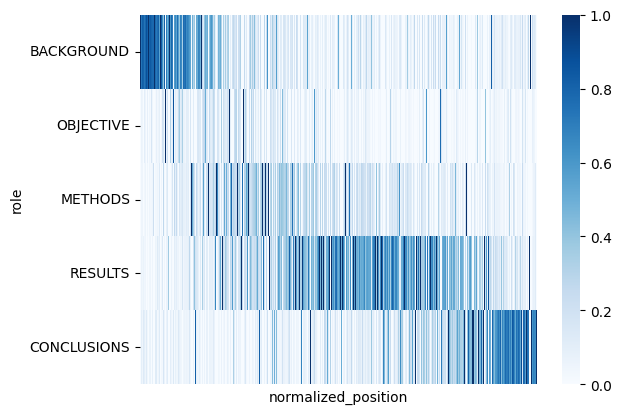

In [224]:
import seaborn as sns

sns.heatmap(abs_mean_plot_df.T.reindex(['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']),
            xticklabels=False, cmap='Blues',
            )

In [225]:
human_df_plot = pd.DataFrame(columns=['normalized_position', 'role', 'probability'])
df_list = []

for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    if row['human_word_prob'] == []:
        continue
    df_melted = pd.DataFrame(row['human_word_prob']).melt(id_vars=['normalized_position'], var_name='role', value_name='probability')
    df_list.append(df_melted.dropna().reset_index(drop=True))

human_df_plot = pd.concat(df_list, ignore_index=True)
human_df_plot

100%|████████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:33<00:00, 999.14it/s]


,normalized_position,role,probability
0,0.000000,BACKGROUND,0.0
1,0.071429,BACKGROUND,1.0
2,0.142857,BACKGROUND,1.0
3,0.214286,BACKGROUND,0.0
4,0.285714,BACKGROUND,0.0
...,...,...,...
2736781,0.826087,NOVEL,1.0
2736782,0.869565,NOVEL,1.0
2736783,0.913043,NOVEL,1.0
2736784,0.956522,NOVEL,0.0


In [226]:
human_mean_plot_df = human_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)
# human_mean_plot_df = human_mean_plot_df.div(human_mean_plot_df.sum(axis=1), axis=0)
human_mean_plot_df

/tmp/ipykernel_904933/3148390018.py:1: FutureWarning: The provided callable <function mean at 0x7f93341763e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  human_mean_plot_df = human_df_plot.pivot_table(index='normalized_position', columns='role', values='probability', aggfunc=np.mean).fillna(0)


role,BACKGROUND,CONCLUSIONS,METHODS,NOVEL,OBJECTIVE,RESULTS
normalized_position,,,,,,
0.000000,0.013199,0.017779,0.017823,0.916603,0.021994,0.012601
0.014925,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.015625,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
0.016393,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
0.016949,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
0.983051,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000
0.983607,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
0.984375,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


<Axes: xlabel='normalized_position', ylabel='role'>

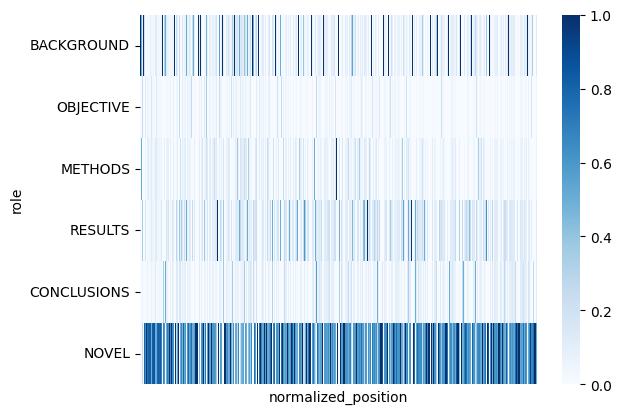

In [227]:
sns.heatmap(human_mean_plot_df.T.reindex(['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'NOVEL']),
            xticklabels=False, cmap='Blues'
            )

# Prepare plot data

In [12]:
def concat_word_probs(df_filtered, model_name: str):
    """Step 1: 拼接所有文档的 word_prob（耗时）"""
    df_list = []
    
    for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
        if row[f'{model_name}_word_prob'] == []:
            continue
        df_melted = pd.DataFrame(row[f'{model_name}_word_prob']).melt(
            id_vars=['normalized_position'], var_name='role', value_name='probability')
        df_list.append(df_melted.dropna())
    
    return pd.concat(df_list, ignore_index=True)

# Step 1: 运行一次，缓存结果（耗时）
abs_concat = concat_word_probs(df_filtered, 'abs')
human_concat = concat_word_probs(df_filtered, 'human')
gemma3_concat = concat_word_probs(df_filtered, 'gemma3')
deepseek_r1_concat = concat_word_probs(df_filtered, 'deepseek_r1')
gpt_oss_concat = concat_word_probs(df_filtered, 'gpt_oss')
llama4_concat = concat_word_probs(df_filtered, 'llama4')
qwen3_concat = concat_word_probs(df_filtered, 'qwen3')

100%|████████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:37<00:00, 899.64it/s]


In [13]:
def bin_and_aggregate(df_concat, n_bins=30):
    """Step 2: 分箱聚合（快速）"""
    bin_edges = np.linspace(0, 1, n_bins + 1).tolist()
    
    df_binned = df_concat.copy()
    df_binned['position_bin'] = pd.cut(
        df_binned['normalized_position'], 
        bins=bin_edges, 
        labels=range(n_bins),
        include_lowest=True
    )
    
    plot_df = df_binned.pivot_table(
        index='position_bin', 
        columns='role', 
        values='probability', 
        aggfunc='mean'
    ).fillna(0)
    
    return plot_df

# Step 2: 快速调整分箱参数
n_bins = 20
abs_plot_df = bin_and_aggregate(abs_concat, n_bins)
human_plot_df = bin_and_aggregate(human_concat, n_bins)
gemma3_plot_df = bin_and_aggregate(gemma3_concat, n_bins)
deepseek_r1_plot_df = bin_and_aggregate(deepseek_r1_concat, n_bins)
gpt_oss_plot_df = bin_and_aggregate(gpt_oss_concat, n_bins)
llama4_plot_df = bin_and_aggregate(llama4_concat, n_bins)
qwen3_plot_df = bin_and_aggregate(qwen3_concat, n_bins)

/tmp/ipykernel_1415657/3025148489.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1415657/3025148489.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1415657/3025148489.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = df_binned.pivot_table(
/tmp/ipykernel_1415657/3025148489.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a futu

In [19]:
for plot_df in [abs_plot_df, human_plot_df, gemma3_plot_df, deepseek_r1_plot_df, gpt_oss_plot_df, llama4_plot_df, qwen3_plot_df]:
    print(f"Mean NOVEL:")
    print(plot_df.NOVEL.mean())

Mean NOVEL:
0.0
Mean NOVEL:
0.6201161864464668
Mean NOVEL:
0.44750268113948133
Mean NOVEL:
0.41288276090272336
Mean NOVEL:
0.4578283714051582
Mean NOVEL:
0.5443020103525862
Mean NOVEL:
0.5594539047026837


# Plot

/tmp/ipykernel_904933/614611577.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Patch(facecolor=plt.cm.get_cmap(role_colors[role])(0.7), label=decapitalize_role[role])


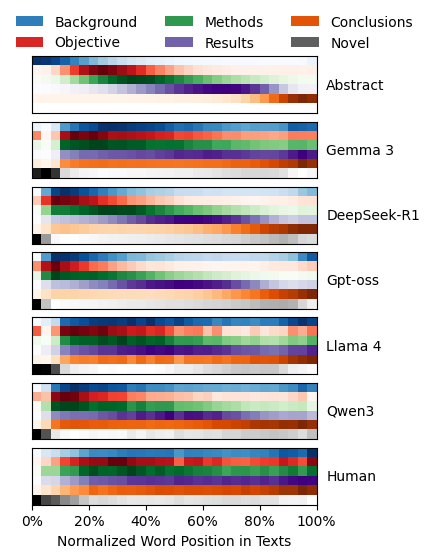

In [589]:
from matplotlib import pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import numpy as np

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS', 'NOVEL']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

def plot_multicolor_heatmap(df, ax):
    data = df.T.reindex(role_order)
    
    for i, role in enumerate(role_order):
        row_data = data.loc[role].values.reshape(1, -1)
        
        im = ax.imshow(row_data, aspect='equal', cmap=role_colors[role], interpolation='nearest', 
                       norm=colors.PowerNorm(gamma=1),
                       extent=[0, row_data.shape[1], i + 1, i])
    
    ax.set_ylim(len(role_order), 0)
    ax.set_xlim(0, data.shape[1])
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

gs_kw = dict(width_ratios=[25], height_ratios=[1, 1, 1, 1, 1, 1, 1])
fig, axes = plt.subplots(7, 1, gridspec_kw=gs_kw, figsize=(8, 5), layout="constrained")

dfs = [abs_plot_df, gemma3_plot_df, deepseek_r1_plot_df, 
       gpt_oss_plot_df, llama4_plot_df, qwen3_plot_df, human_plot_df]
titles = ['Abstract', 'Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

for ax, df, title in zip(axes, dfs, titles):
    plot_multicolor_heatmap(df, ax)
    # 把 title 移到右侧，作为 ylabel
    ax.yaxis.set_label_position("right")
    ax.set_ylabel(title, rotation=0, ha='left', va='center', fontsize=10, labelpad=7)

axes[-1].set_xlabel('Normalized Word Position in Texts')
axes[-1].set_xticks(np.linspace(0, n_bins, 6))
axes[-1].set_xticklabels([f"{i*20}%" for i in range(6)])

legend_patches = [
    Patch(facecolor=plt.cm.get_cmap(role_colors[role])(0.7), label=decapitalize_role[role])
    for role in role_order
]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.55, 1.10),
           ncol=len(role_order)/2, frameon=False, fontsize=10)

plt.show()

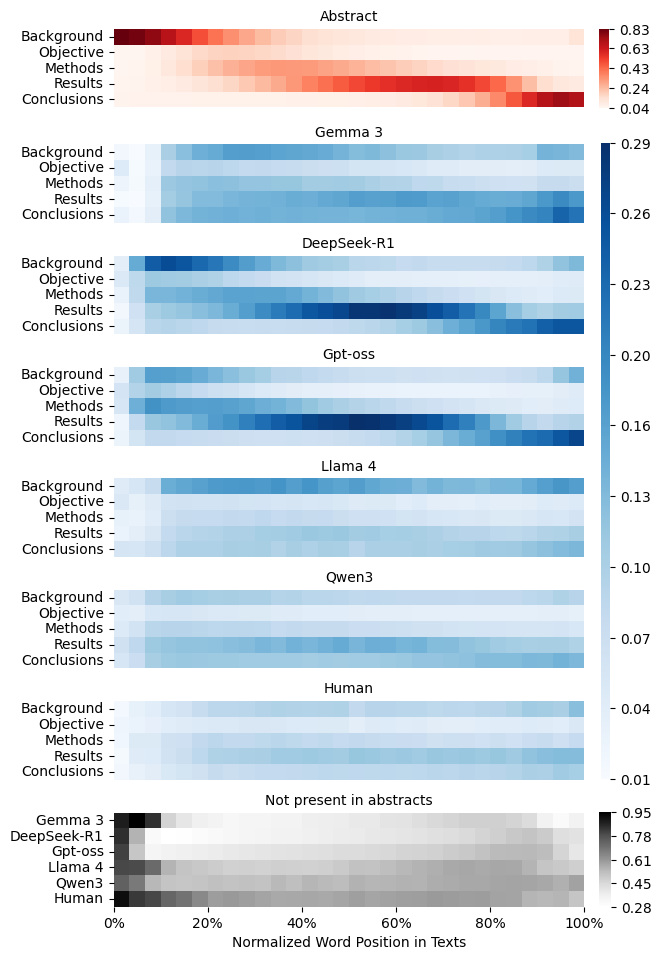

In [605]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_order_abs = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_model_role_matrix(model, all_dfs, role_order):
    """构建某个 model 中所有 role 的数据矩阵（行是 role，列是 position）"""
    df = all_dfs[model]
    rows = []
    for role in role_order:
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

def get_novel_data_matrix(all_dfs, model_order):
    """构建所有 model 的 NOVEL 数据矩阵（行是 model，列是 position）"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if 'NOVEL' in df.columns:
            rows.append(df['NOVEL'].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

# 创建图：
# 1. Abstract 子图 (5 行 role)
# 2. 6 个 model 子图 (每个 5 行 role)
# 3. NOVEL 子图 (6 行 model)
# 共 8 个子图
fig = plt.figure(figsize=(6.5, 9.5), layout="constrained")
height_ratios = [5] + [5] * 6 + [6]  # Abstract, 6 models, NOVEL
gs = gridspec.GridSpec(8, 1, figure=fig, height_ratios=height_ratios)

n_ticks = 5
gs_idx = 0

# 1. 绘制 Abstract 子图（红色）
ax_abs = fig.add_subplot(gs[gs_idx])
gs_idx += 1

abs_data_matrix = get_model_role_matrix('abs', all_plot_dfs, role_order_abs)
abs_vmin, abs_vmax = abs_data_matrix.min(), abs_data_matrix.max()

hm_abs = sns.heatmap(abs_data_matrix, ax=ax_abs, square=True, cmap='Reds',
                      cbar=True,
                      cbar_kws={'shrink': .9, 'aspect': 8, 'pad': -0.01},
                      vmin=abs_vmin, vmax=abs_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)

cbar = hm_abs.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_abs.set_title('Abstract', fontsize=10, loc='center')
ax_abs.set_ylabel('')

# 2. 绘制 6 个 model 子图（蓝色，每个有自己的 colorbar）

# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())

for model, model_name in zip(model_order, model_names):
    ax = fig.add_subplot(gs[gs_idx])
    gs_idx += 1
    
    data_matrix = get_model_role_matrix(model, all_plot_dfs, role_order_abs)
    vmin, vmax = data_matrix.min(), data_matrix.max()
    
    hm = sns.heatmap(data_matrix, ax=ax, square=True, cmap='Blues',
                      cbar=False,
                      vmin=global_sum_vmin, vmax=global_sum_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)
    
    ax.set_title(model_name, fontsize=10, loc='center')
    ax.set_ylabel('')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.915, 0.185, 0.015, 0.67])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 3. 绘制 NOVEL 子图（灰色）
ax_novel = fig.add_subplot(gs[gs_idx])

novel_data_matrix = get_novel_data_matrix(all_plot_dfs, model_order)
novel_vmin, novel_vmax = novel_data_matrix.min(), novel_data_matrix.max()

hm_novel = sns.heatmap(novel_data_matrix, ax=ax_novel, square=True, cmap='Greys',
                        cbar=True,
                        cbar_kws={'shrink': .9, 'aspect': 8, 'pad': -0.01},
                        vmin=novel_vmin, vmax=novel_vmax,
                        xticklabels=False,
                        yticklabels=model_names,
                        rasterized=True)

cbar = hm_novel.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_novel.set_title(decapitalize_role['NOVEL'], fontsize=10, loc='center')
ax_novel.set_ylabel('')

# 最后一个子图添加 x 轴标签
ax_novel.set_xticks(np.linspace(0, n_bins, 6))
ax_novel.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_novel.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [606]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_1.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

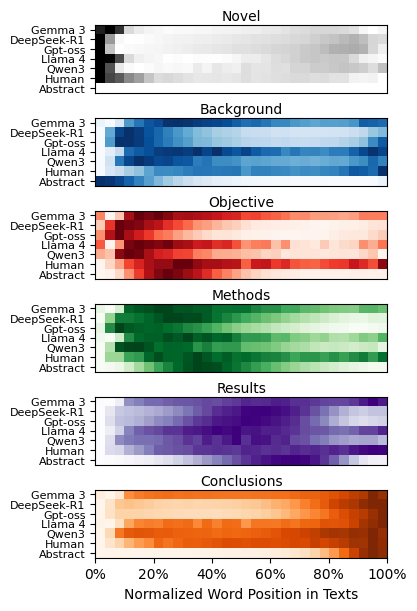

In [609]:
from matplotlib import pyplot as plt
import numpy as np

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human', 'abs']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human', 'Abstract']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

global_vmax = max(
    df.values.max() for df in all_plot_dfs.values()
)
global_vmin = min(
    df.values.min() for df in all_plot_dfs.values()
)

def plot_role_across_models(role, ax, all_dfs, model_order):
    """绘制同一个 role 在不同 model 中的分布"""
    n_models = len(model_order)
    cmap = role_colors[role]
    
    for i, model in enumerate(model_order):
        df = all_dfs[model]
        if role in df.columns:
            row_data = df[role].values.reshape(1, -1)
        else:
            row_data = np.zeros((1, len(df)))
        
        im = ax.imshow(row_data, aspect='equal', cmap=cmap, 
                       interpolation='None',
                       # vmin=global_vmin, vmax=global_vmax,
                       extent=[0, row_data.shape[1], i + 1, i])
    
    ax.set_ylim(n_models, 0)
    ax.set_xlim(0, row_data.shape[1])
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# 创建图：5 行（5 个 role），每行 1 个子图
fig, axes = plt.subplots(6, 1, figsize=(10, 6), layout="constrained")

for ax, role in zip(axes, role_order):
    plot_role_across_models(role, ax, all_plot_dfs, model_order)
    
    # role 名称放在右侧
    ax.set_title(decapitalize_role[role], ha='center', va='center', fontsize=10, loc='center')
    
    # y 轴显示 model 名称
    ax.set_yticks(np.arange(0.5, len(model_order), 1))
    ax.set_yticklabels(model_names, fontsize=8)

# 最后一个子图添加 x 轴标签
axes[-1].set_xlabel('Normalized Word Position in Texts')
axes[-1].set_xticks(np.linspace(0, n_bins, 6))
axes[-1].set_xticklabels([f"{i*20}%" for i in range(6)])

plt.show()

In [610]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_4.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

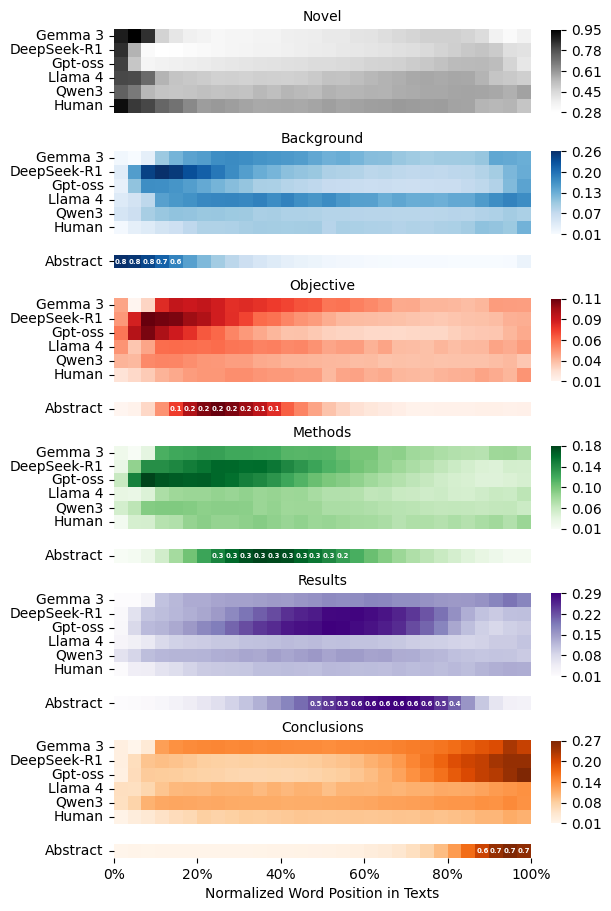

In [325]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_colors = {
    'BACKGROUND': 'Blues',
    'OBJECTIVE': 'Reds',
    'METHODS': 'Greens',
    'RESULTS': 'Purples',
    'CONCLUSIONS': 'Oranges',
    'NOVEL': 'Greys'
}

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
# 共 11 行：1 (NOVEL) + 2*5 (其他5个role)
fig = plt.figure(figsize=(6, 9), layout="constrained")
# height_ratios: NOVEL 6, 其他每个 role 是 [6, 1]
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0  # 当前 GridSpec 索引

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        # NOVEL 只绘制模型子图，不绘制 abstract
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap=role_colors[role],
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        
    else:
        # 其他 role 绘制模型子图 + abstract 子图
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        abs_vmin, abs_vmax = abs_data.min(), abs_data.max()
        
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap=role_colors[role],
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap=role_colors[role],
                          cbar=False,
                          vmin=abs_vmin, vmax=abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'])
        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)
        
        # 在 abstract heatmap 单元格内标注较大的值
        threshold = abs_vmax * 0.7  # 只标注超过最大值 70% 的 cell
        for col_idx, val in enumerate(abs_data.flatten()):
            if val >= threshold:
                ax_abs.text(col_idx + 0.5, 0.5, f'{val:.1f}', 
                           ha='center', va='center',
                           fontsize=5, color='white', fontweight='bold')
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        ax_abs.set_ylabel('')

# 最后一个 abstract 子图添加 x 轴标签
ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

plt.show()

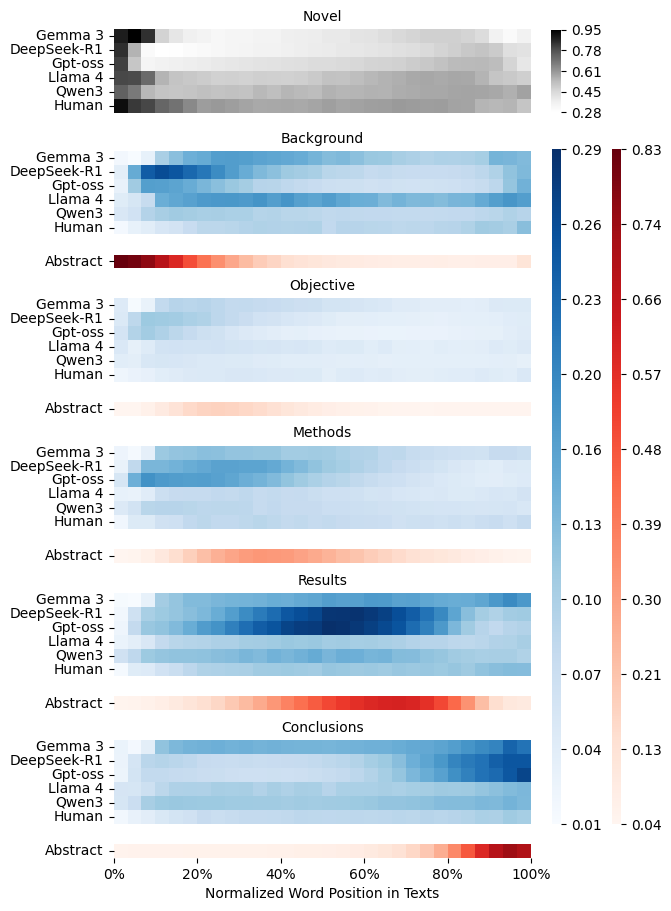

In [366]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Novel'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')
global_abs_vmin = float('inf')
global_abs_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())
    
    # 计算 abstract 的全局 vmin/vmax
    if role in all_plot_dfs['abs'].columns:
        abs_data = all_plot_dfs['abs'][role].values
        global_abs_vmin = min(global_abs_vmin, abs_data.min())
        global_abs_vmax = max(global_abs_vmax, abs_data.max())

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
fig = plt.figure(figsize=(6, 9), layout="constrained")
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        # NOVEL 保持灰色，有自己的 colorbar
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Greys',
                          cbar=True,
                          cbar_kws={'shrink': 0.8, 'aspect': 8, 'pad': 0},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        n_ticks = 5
        cbar = hm1.collections[0].colorbar
        cbar.locator = ticker.LinearLocator(numticks=n_ticks)
        cbar.update_ticks()
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        
    else:
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        # Summary 使用蓝色，使用全局 vmin/vmax，不显示 colorbar
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=False,
                          vmin=global_sum_vmin, vmax=global_sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names)
        
        # Abstract 使用红色，使用全局 abstract vmin/vmax
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap='Reds',
                          cbar=False,
                          vmin=global_abs_vmin, vmax=global_abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'])
        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)
        
        ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
        ax_sum.set_ylabel('')
        ax_abs.set_ylabel('')

ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.91, 0.09, 0.0155, 0.75])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 添加共享的 Abstract colorbar（红色）
norm_abs = Normalize(vmin=global_abs_vmin, vmax=global_abs_vmax)
sm_abs = ScalarMappable(cmap='Reds', norm=norm_abs)
sm_abs.set_array([])
cbar_abs_ax = fig.add_axes([1.01, 0.09, 0.0155, 0.75])
cbar_abs = fig.colorbar(sm_abs, cax=cbar_abs_ax)
cbar_abs.locator = ticker.LinearLocator(numticks=10)
cbar_abs.update_ticks()
cbar_abs.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 隐藏 Abstract colorbar 的 spine
for spine in cbar_abs.ax.spines.values():
    spine.set_visible(False)

plt.show()

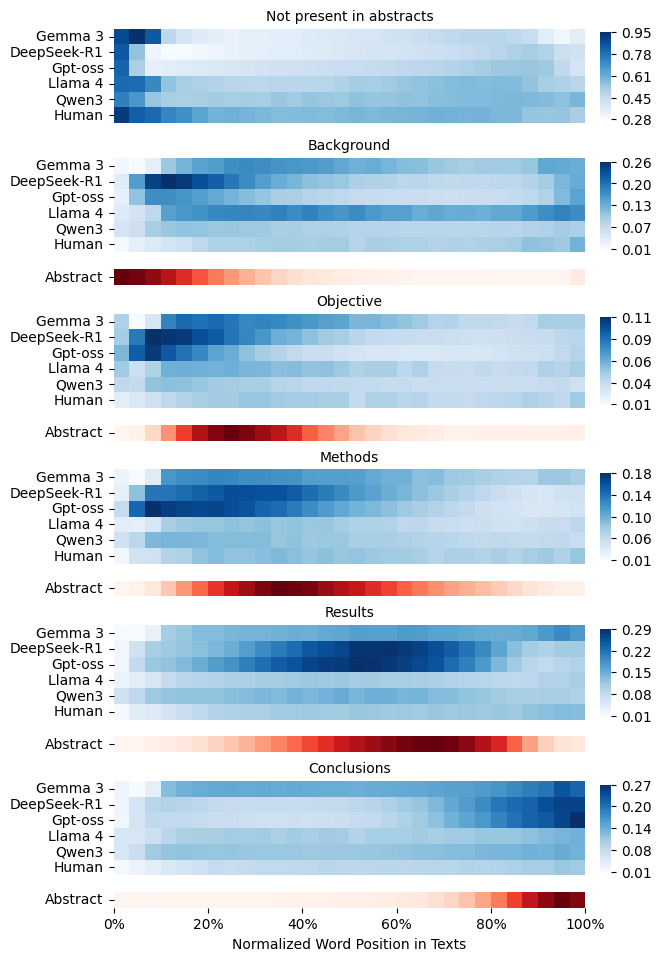

In [611]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_order = ['NOVEL', 'BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

# 创建图：NOVEL 只有 1 个子图，其他 role 有 2 个子图（Summary + abstract）
fig = plt.figure(figsize=(6.5, 9.5), 
                 layout="constrained"
                 )
height_ratios = [6] + [6, 1] * 5
gs = gridspec.GridSpec(11, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

for i, role in enumerate(role_order):
    if role == 'NOVEL':
        ax_sum = fig.add_subplot(gs[gs_idx])
        gs_idx += 1
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        
        # NOVEL 保持灰色
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=True,
                          cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names,
                          rasterized=True
                          )
        
    else:
        ax_sum = fig.add_subplot(gs[gs_idx])
        ax_abs = fig.add_subplot(gs[gs_idx + 1])
        gs_idx += 2
        
        data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
        abs_data = all_plot_dfs['abs'][role].values.reshape(1, -1) if role in all_plot_dfs['abs'].columns else np.zeros((1, n_bins))
        
        sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
        abs_vmin, abs_vmax = abs_data.min(), abs_data.max()
        
        # Summary 使用蓝色
        hm1 = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                          cbar=True,
                          cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                          vmin=sum_vmin, vmax=sum_vmax,
                          xticklabels=False,
                          yticklabels=model_names,
                          rasterized=True
                          )
        
        # Abstract 使用红色
        hm2 = sns.heatmap(abs_data, ax=ax_abs, square=True, cmap='Reds',
                          cbar=False,
                          vmin=abs_vmin, vmax=abs_vmax,
                          xticklabels=False,
                          yticklabels=['Abstract'],
                          rasterized=True
                          )

        ax_abs.set_yticklabels(ax_abs.get_yticklabels(), rotation=0)

    n_ticks = 5
    cbar = hm1.collections[0].colorbar
    
    cbar.locator = ticker.LinearLocator(numticks=n_ticks)
    cbar.update_ticks()
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
    ax_sum.set_ylabel('')
    ax_abs.set_ylabel('')

ax_abs.set_xticks(np.linspace(0, n_bins, 6))
ax_abs.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_abs.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [612]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_2.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

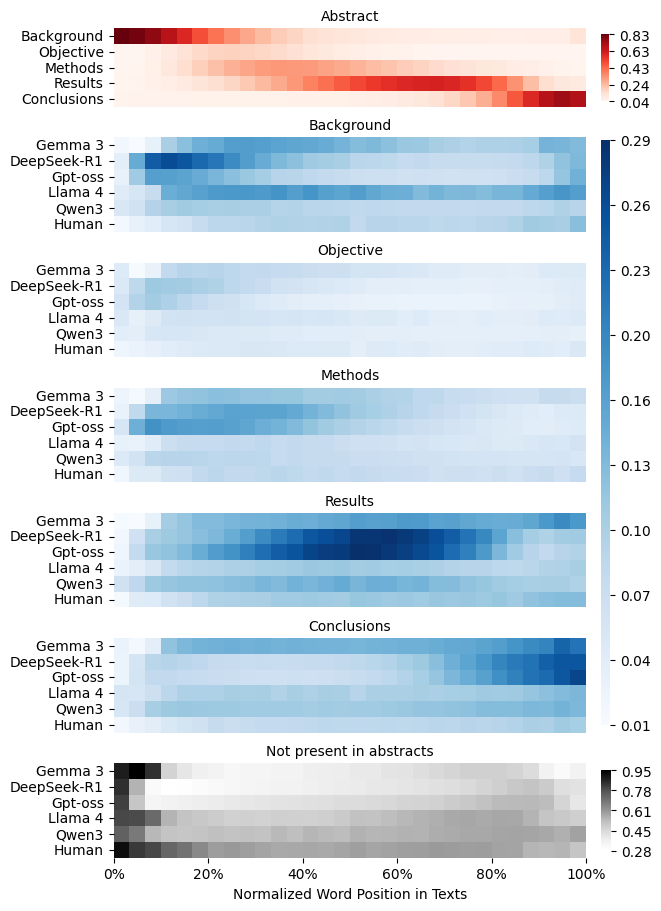

In [613]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

role_order_abs = ['BACKGROUND', 'OBJECTIVE', 'METHODS', 'RESULTS', 'CONCLUSIONS']
role_order_novel = ['NOVEL']
model_order = ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']
model_names = ['Gemma 3', 'DeepSeek-R1', 'Gpt-oss', 'Llama 4', 'Qwen3', 'Human']

decapitalize_role = {
    'BACKGROUND': 'Background',
    'OBJECTIVE': 'Objective',
    'METHODS': 'Methods',
    'RESULTS': 'Results',
    'CONCLUSIONS': 'Conclusions',
    'NOVEL': 'Not present in abstracts'
}

# 收集所有 binned 数据
all_plot_dfs = {
    'gemma3': gemma3_plot_df,
    'deepseek_r1': deepseek_r1_plot_df,
    'gpt_oss': gpt_oss_plot_df,
    'llama4': llama4_plot_df,
    'qwen3': qwen3_plot_df,
    'human': human_plot_df,
    'abs': abs_plot_df
}

def get_role_data_matrix(role, all_dfs, model_order):
    """构建某个 role 在所有 model 中的数据矩阵"""
    rows = []
    for model in model_order:
        df = all_dfs[model]
        if role in df.columns:
            rows.append(df[role].values)
        else:
            rows.append(np.zeros(len(df)))
    return np.array(rows)

def get_abs_data_matrix(all_dfs, role_order):
    """构建 abstract 中所有 role 的数据矩阵"""
    rows = []
    for role in role_order:
        if role in all_dfs['abs'].columns:
            rows.append(all_dfs['abs'][role].values)
        else:
            rows.append(np.zeros(n_bins))
    return np.array(rows)

# 创建图：
# 1. Abstract 子图 (5 行，每行一个 role)
# 2. NOVEL 子图 (6 行，每行一个 model)
# 3. 其他 5 个 role 的 Summary 子图 (每个 6 行)
# height_ratios: Abstract 5, NOVEL 6, 其他每个 role 6
fig = plt.figure(figsize=(6.5, 9), layout="constrained")
height_ratios = [5] + [6] + [6] * 5  # Abstract, NOVEL, 5 个其他 role
gs = gridspec.GridSpec(7, 1, figure=fig, height_ratios=height_ratios)

gs_idx = 0

# 1. 绘制 Abstract 子图（所有 role 在一起）
ax_abs = fig.add_subplot(gs[gs_idx])
gs_idx += 1

abs_data_matrix = get_abs_data_matrix(all_plot_dfs, role_order_abs)
abs_vmin, abs_vmax = abs_data_matrix.min(), abs_data_matrix.max()

hm_abs = sns.heatmap(abs_data_matrix, ax=ax_abs, square=True, cmap='Reds',
                      cbar=True,
                      cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                      vmin=abs_vmin, vmax=abs_vmax,
                      xticklabels=False,
                      yticklabels=[decapitalize_role[r] for r in role_order_abs],
                      rasterized=True)

n_ticks = 5
cbar = hm_abs.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_abs.set_title('Abstract', fontsize=10, loc='center')
ax_abs.set_ylabel('')

# 3. 绘制其他 5 个 role 的 Summary 子图
# 计算所有非 NOVEL role 的 Summary 全局 vmin/vmax
non_novel_roles = [r for r in role_order if r != 'NOVEL']
global_sum_vmin = float('inf')
global_sum_vmax = float('-inf')

for role in non_novel_roles:
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    global_sum_vmin = min(global_sum_vmin, data_matrix.min())
    global_sum_vmax = max(global_sum_vmax, data_matrix.max())

for role in role_order_abs:
    ax_sum = fig.add_subplot(gs[gs_idx])
    gs_idx += 1
    
    data_matrix = get_role_data_matrix(role, all_plot_dfs, model_order)
    sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()
    
    hm = sns.heatmap(data_matrix, ax=ax_sum, square=True, cmap='Blues',
                      cbar=False,
                      cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                      vmin=global_sum_vmin, vmax=global_sum_vmax,
                      xticklabels=False,
                      yticklabels=model_names,
                      rasterized=True)
    
    # cbar = hm.collections[0].colorbar
    # cbar.locator = ticker.LinearLocator(numticks=n_ticks)
    # cbar.update_ticks()
    # cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    ax_sum.set_title(decapitalize_role[role], fontsize=10, loc='center')
    ax_sum.set_ylabel('')

# 添加共享的 Summary colorbar（蓝色）
norm_sum = Normalize(vmin=global_sum_vmin, vmax=global_sum_vmax)
sm_sum = ScalarMappable(cmap='Blues', norm=norm_sum)
sm_sum.set_array([])
cbar_sum_ax = fig.add_axes([0.915, 0.2, 0.015, 0.65])
cbar_sum = fig.colorbar(sm_sum, cax=cbar_sum_ax)
cbar_sum.locator = ticker.LinearLocator(numticks=10)
cbar_sum.update_ticks()
cbar_sum.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# 隐藏 Summary colorbar 的 spine
for spine in cbar_sum.ax.spines.values():
    spine.set_visible(False)

# 2. 绘制 NOVEL 子图
ax_novel = fig.add_subplot(gs[gs_idx])
gs_idx += 1

data_matrix = get_role_data_matrix('NOVEL', all_plot_dfs, model_order)
sum_vmin, sum_vmax = data_matrix.min(), data_matrix.max()

hm_novel = sns.heatmap(data_matrix, ax=ax_novel, square=True, cmap='Greys',
                        cbar=True,
                        cbar_kws={'shrink': .8, 'aspect': 8, 'pad': -0.01},
                        vmin=sum_vmin, vmax=sum_vmax,
                        xticklabels=False,
                        yticklabels=model_names,
                        rasterized=True)

cbar = hm_novel.collections[0].colorbar
cbar.locator = ticker.LinearLocator(numticks=n_ticks)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax_novel.set_title(decapitalize_role['NOVEL'], fontsize=10, loc='center')
ax_novel.set_ylabel('')


# 最后一个子图添加 x 轴标签
ax_novel.set_xticks(np.linspace(0, n_bins, 6))
ax_novel.set_xticklabels([f"{i*20}%" for i in range(6)])
ax_novel.set_xlabel('Normalized Word Position in Texts')

plt.show()

In [614]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure_3.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

# Save fig

In [587]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/rhetorical_structure.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )

In [473]:
from tqdm import tqdm

results = {'gemma3': {}, 'deepseek_r1': {}, 'gpt_oss': {}, 'llama4': {}, 'qwen3': {}, 'human': {}}
for index, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    for model in ['gemma3', 'deepseek_r1', 'gpt_oss', 'llama4', 'qwen3', 'human']:
        for word, role_prob_dict in zip(row[f'{model}_words'], row[f'{model}_word_prob']):
            if role_prob_dict['NOVEL'] == 1.0 and role_prob_dict['normalized_position'] < 0.2:
                results[model][word] = results[model].get(word, 0) + 1

100%|██████████████████████████████████████████████████████████████████████████████████████| 33850/33850 [00:02<00:00, 15802.57it/s]


,gemma3,deepseek_r1,gpt_oss,llama4,qwen3,human
study,9149.0,25933.0,15767.0,17937.0,23651.0,6907.0
demonstrates,8631.0,5993.0,4817.0,2942.0,6556.0,1192.0
identifies,2302.0,7217.0,2111.0,4181.0,11100.0,426.0
work,7354.0,22.0,1328.0,1267.0,2055.0,1092.0
paper,3148.0,1031.0,525.0,569.0,1287.0,6067.0
shows,1695.0,34.0,5122.0,1297.0,885.0,2231.0
reports,4644.0,256.0,529.0,2495.0,690.0,986.0
investigates,101.0,8061.0,25.0,447.0,13.0,47.0
authors,31.0,14.0,6181.0,1127.0,63.0,738.0
describes,3406.0,478.0,172.0,862.0,477.0,1523.0


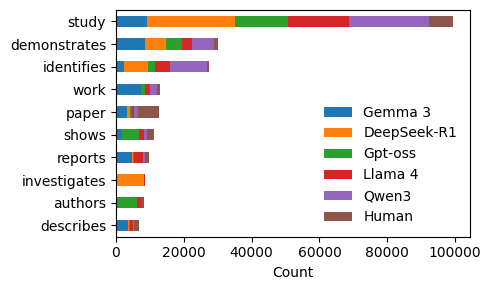

In [557]:
import seaborn as sns

model_name_dict = {
    'gemma3': 'Gemma 3',
    'deepseek_r1': 'DeepSeek-R1',
    'gpt_oss': 'Gpt-oss',
    'llama4': 'Llama 4',
    'qwen3': 'Qwen3',
    'human': 'Human'
}

top_10_novel_words_df = pd.DataFrame.from_dict(results, orient='columns').loc[pd.DataFrame.from_dict(results, orient='columns').sum(axis=1).sort_values(ascending=False)[0:10].index]

display(top_10_novel_words_df)

# 重命名列
top_10_novel_words_df = top_10_novel_words_df.rename(columns=model_name_dict)

fig, ax = plt.subplots(figsize=(5, 3))

# 使用 pandas 的 barh 绘制堆叠条形图
top_10_novel_words_df.plot.barh(stacked=True, ax=ax)

ax.set_xlabel('Count')
ax.set_ylabel('')
ax.legend(frameon=False, title='', loc='lower right')
ax.invert_yaxis()  # 让最多的在上面

plt.tight_layout()
plt.show()

In [558]:
fig.savefig('/home/zqlyu2/projects/TLDR/dataset_description/novel_top10_words.pdf', 
            dpi=300, 
            bbox_inches='tight'
            )